# Pensamiento Sistémico e Introducción a la Simulación

**Curso:** Modelado Bajo Incertidumbre  
**Autor:** Alejandra Tabares Pozos  
**Instituto:** Universidad de los Andes - Departamento de Ingeniería Industrial


In [7]:
# ============================================================
# LIBRERÍAS NECESARIAS
# ============================================================
# Estas son las herramientas que usaremos para hacer simulaciones

import numpy as np              # Para trabajar con números y generar aleatoriedad
import matplotlib.pyplot as plt # Para hacer gráficas
import pandas as pd             # Para trabajar con tablas de datos
import seaborn as sns           # Para hacer gráficas más bonitas
from scipy import stats         # Para estadísticas avanzadas
from scipy.stats import norm, expon, poisson  # Distribuciones de probabilidad
import warnings
warnings.filterwarnings('ignore')  # Ocultar mensajes de advertencia

# ============================================================
# CONFIGURACIÓN DE ESTILO DE GRÁFICAS
# ============================================================
plt.style.use('seaborn-v0_8-darkgrid')  # Estilo visual de las gráficas
sns.set_palette("husl")                  # Paleta de colores

# ============================================================
# SEMILLA ALEATORIA
# ============================================================
# Esto hace que los números "aleatorios" sean siempre los mismos
# Es útil para que todos obtengamos los mismos resultados
np.random.seed(42)

## 1. Definición de Sistema

Un **sistema** se define como una agregación o ensamblaje de objetos unidos en alguna interacción o interdependencia regular hacia el logro de algún propósito.

### Componentes Clave:

- **Entidad:** Objeto de interés en el sistema (ej. una máquina, un cliente)
- **Atributo:** Propiedad de una entidad (ej. velocidad de la máquina, saldo del cliente)
- **Actividad:** Proceso que causa cambios en el sistema (ej. soldar, depositar)
- **Estado del Sistema:** Colección de variables necesarias para describir el sistema en cualquier momento $t$

El estado del sistema se puede representar como:

$$S(t) = (x_1(t), x_2(t), \dots, x_n(t))$$

**Ejemplo (Banco):**
$$S(t) = (\text{Cajeros ocupados}, \text{Personas en fila}, \text{Hora actual})$$


## 3. La Falacia del Promedio

**Problema fundamental:** Evaluar una función no lineal en el valor esperado de la entrada **NO es igual** al valor esperado de la salida.

$$E[f(X)] \neq f(E[X])$$

(A menos que $f$ sea lineal - ver Desigualdad de Jensen)

En Ingeniería Industrial, las funciones de costo, espera y congestión son casi siempre **no lineales** y convexas. Usar promedios subestima sistemáticamente el riesgo.

### Ejemplo Visual: Función No Lineal


DEMOSTRACIÓN DE LA FALACIA DEL PROMEDIO

1. Promedio de X:              -0.002
2. Promedio de f(X) = X²:      1.007  ← Valor CORRECTO
3. f(Promedio de X):           0.000  ← ¡ERROR!

Diferencia (el error):         1.007

¡Usar el promedio subestima el resultado real!


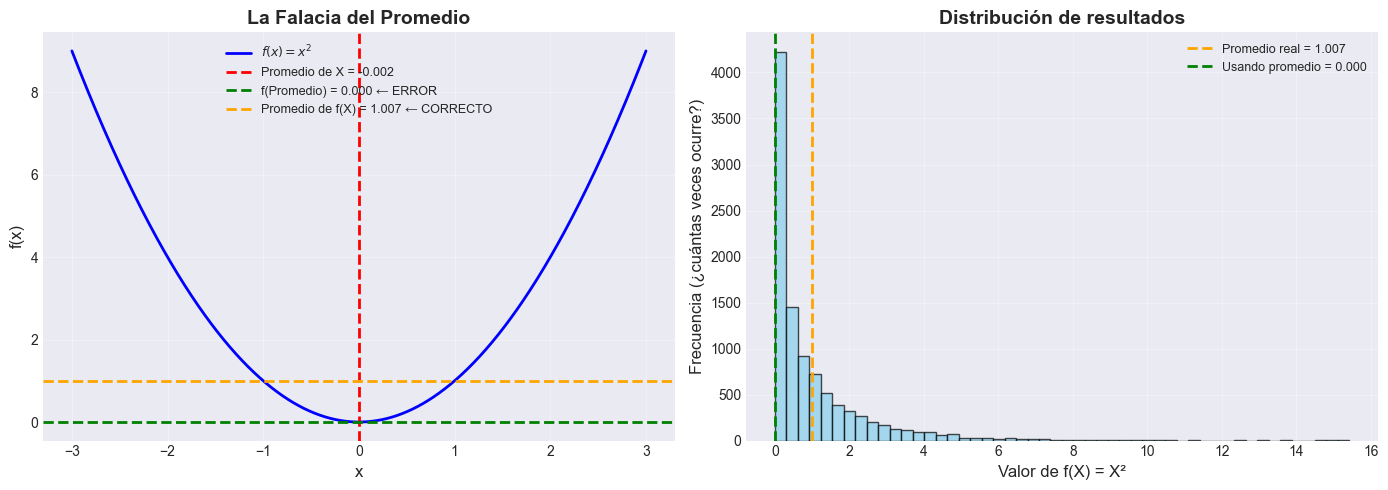

In [8]:
# ============================================================
# EJEMPLO: La Falacia del Promedio con f(x) = x²
# ============================================================

# Definimos una función no lineal: f(x) = x²
x = np.linspace(-3, 3, 1000)  # Creamos 1000 puntos entre -3 y 3
f_x = x**2                     # Calculamos x² para cada punto

# ============================================================
# GENERACIÓN DE NÚMEROS ALEATORIOS
# ============================================================
# Generamos 10,000 números aleatorios que siguen una distribución Normal(0,1)
# Esto significa: promedio = 0, desviación estándar = 1
numero_simulaciones = 10000
X_muestras = np.random.normal(loc=0, scale=1, size=numero_simulaciones)

# Aplicamos la función f(x) = x² a cada número aleatorio
f_X_muestras = X_muestras**2

# ============================================================
# CÁLCULO DE PROMEDIOS
# ============================================================
# Promedio de X (debería ser cercano a 0)
promedio_X = np.mean(X_muestras)

# Promedio de f(X) = X² (este es el VALOR REAL que buscamos)
promedio_f_X = np.mean(f_X_muestras)

# f(Promedio de X) = (Promedio de X)² (este es el ERROR común)
f_promedio_X = promedio_X**2

print("=" * 60)
print("DEMOSTRACIÓN DE LA FALACIA DEL PROMEDIO")
print("=" * 60)
print(f"\n1. Promedio de X:              {promedio_X:.3f}")
print(f"2. Promedio de f(X) = X²:      {promedio_f_X:.3f}  ← Valor CORRECTO")
print(f"3. f(Promedio de X):           {f_promedio_X:.3f}  ← ¡ERROR!")
print(f"\nDiferencia (el error):         {promedio_f_X - f_promedio_X:.3f}")
print("\n¡Usar el promedio subestima el resultado real!")
print("=" * 60)

# ============================================================
# VISUALIZACIÓN
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- GRÁFICA 1: La función f(x) = x² ---
axes[0].plot(x, f_x, 'b-', linewidth=2, label=r'$f(x) = x^2$')
axes[0].axvline(promedio_X, color='red', linestyle='--', linewidth=2, 
                label=f'Promedio de X = {promedio_X:.3f}')
axes[0].axhline(f_promedio_X, color='green', linestyle='--', linewidth=2, 
                label=f'f(Promedio) = {f_promedio_X:.3f} ← ERROR')
axes[0].axhline(promedio_f_X, color='orange', linestyle='--', linewidth=2, 
                label=f'Promedio de f(X) = {promedio_f_X:.3f} ← CORRECTO')
axes[0].set_xlabel('x', fontsize=12)
axes[0].set_ylabel('f(x)', fontsize=12)
axes[0].set_title('La Falacia del Promedio', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# --- GRÁFICA 2: Distribución de los resultados ---
axes[1].hist(f_X_muestras, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[1].axvline(promedio_f_X, color='orange', linestyle='--', linewidth=2, 
                label=f'Promedio real = {promedio_f_X:.3f}')
axes[1].axvline(f_promedio_X, color='green', linestyle='--', linewidth=2, 
                label=f'Usando promedio = {f_promedio_X:.3f}')
axes[1].set_xlabel('Valor de f(X) = X²', fontsize=12)
axes[1].set_ylabel('Frecuencia (¿cuántas veces ocurre?)', fontsize=12)
axes[1].set_title('Distribución de resultados', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Definición de Simulación

> "La simulación es la imitación de la operación de un proceso o sistema del mundo real a lo largo del tiempo." -- Banks

### Características:

- Generación de una historia artificial del sistema
- Observación de esa historia para hacer inferencias
- Es una técnica **numérica**, no analítica

### Cuándo es Apropiada la Simulación


#### Ejemplo 1: Simulación de Lanzamiento de Dados

**Pregunta:** ¿Cuál es la probabilidad de obtener una secuencia específica, por ejemplo "11111" (cinco unos seguidos) al lanzar un dado 5 veces?

---

### 🎲 ¿Qué vamos a hacer?

Imagina que queremos saber la probabilidad de lanzar un dado 5 veces y obtener "11111" (cinco unos consecutivos). Podríamos:

1. **Calcularlo matemáticamente** (enfoque analítico):
   - Cada lanzamiento tiene probabilidad 1/6 de ser "1"
   - Para 5 lanzamientos independientes: P = (1/6) × (1/6) × (1/6) × (1/6) × (1/6) = 1/7,776
   
2. **Simularlo con código** (enfoque por simulación):
   - Lanzamos el dado 5 veces
   - Repetimos esto MUCHAS veces (por ejemplo, 1 millón de veces)
   - Contamos cuántas veces obtuvimos "11111"
   - Calculamos: P ≈ (veces que ocurrió) / (intentos totales)

---

### 💡 ¿Por qué es útil la simulación?

- **Valida los cálculos teóricos:** Si nuestra simulación da un resultado similar a la teoría, ¡bien!
- **Funciona cuando la teoría es complicada:** Algunos problemas son muy difíciles de resolver matemáticamente
- **Es intuitiva:** Es más fácil entender "lancé el dado 1 millón de veces" que una fórmula compleja

---

**Enfoque analítico:**

$$P(\text{secuencia específica}) = \left(\frac{1}{6}\right)^5 = \frac{1}{7776} \approx 0.0001286$$

**Enfoque por simulación:** 

Vamos a programarlo y ver qué obtenemos...

In [9]:
# ============================================================
# EJEMPLO 1: SIMULACIÓN DE LANZAMIENTO DE DADOS
# ============================================================

def lanzar_dado():
    """
    Simula el lanzamiento de un dado de 6 caras.
    
    Retorna:
        Un número entero aleatorio entre 1 y 6
    """
    # Elegimos aleatoriamente un número del 1 al 6
    resultado = np.random.choice([1, 2, 3, 4, 5, 6])
    return resultado


def simular_secuencia(longitud_secuencia=5):
    """
    Simula múltiples lanzamientos de dado y los convierte en una secuencia.
    
    Parámetros:
        longitud_secuencia: ¿Cuántas veces lanzamos el dado?
    
    Retorna:
        Un string con la secuencia (ejemplo: "14256")
    """
    secuencia = ''  # Empezamos con una secuencia vacía
    
    # Lanzamos el dado 'longitud_secuencia' veces
    for i in range(longitud_secuencia):
        resultado = lanzar_dado()
        secuencia = secuencia + str(resultado)  # Agregamos el resultado a la secuencia
    
    return secuencia


def calcular_probabilidad_simulacion(secuencia_objetivo, numero_intentos):
    """
    Calcula la probabilidad de obtener una secuencia específica mediante simulación.
    
    Parámetros:
        secuencia_objetivo: La secuencia que queremos obtener (ejemplo: '11111')
        numero_intentos: ¿Cuántos experimentos hacemos?
    
    Retorna:
        probabilidad_teorica: La probabilidad según la teoría matemática
        probabilidad_estimada: La probabilidad según nuestra simulación
        veces_que_ocurrio: Cuántas veces obtuvimos la secuencia
    """
    
    # Contador: ¿cuántas veces obtuvimos la secuencia objetivo?
    veces_que_ocurrio = 0
    longitud = len(secuencia_objetivo)
    
    # Hacemos muchos experimentos
    for intento in range(numero_intentos):
        # Generamos una secuencia aleatoria
        secuencia_generada = simular_secuencia(longitud)
        
        # ¿Es igual a la que buscamos?
        if secuencia_generada == secuencia_objetivo:
            veces_que_ocurrio = veces_que_ocurrio + 1
    
    # Calculamos las probabilidades
    # Teóricamente: P = 1/(6^n) donde n es la longitud de la secuencia
    probabilidad_teorica = 1 / (6 ** longitud)
    
    # Por simulación: P ≈ (veces que ocurrió) / (intentos totales)
    probabilidad_estimada = veces_que_ocurrio / numero_intentos
    
    return probabilidad_teorica, probabilidad_estimada, veces_que_ocurrio


# ============================================================
# EJECUTAR LA SIMULACIÓN
# ============================================================
print("=" * 70)
print("SIMULACIÓN: Probabilidad de obtener una secuencia específica")
print("=" * 70)

# Configuramos el experimento
np.random.seed(42)  # Para que todos tengamos los mismos resultados
secuencia_objetivo = '11111'  # Queremos obtener cinco unos seguidos
numero_intentos = 1000000     # Hacemos 1 millón de intentos

print(f"\nSecuencia que buscamos: {secuencia_objetivo}")
print(f"Número de experimentos: {numero_intentos:,}")
print("\n⏳ Ejecutando simulación...")

# Ejecutamos la simulación
prob_teorica, prob_simulada, ocurrencias = calcular_probabilidad_simulacion(
    secuencia_objetivo, 
    numero_intentos
)

# Mostramos los resultados
print("\n" + "=" * 70)
print("RESULTADOS:")
print("=" * 70)
print(f"Probabilidad teórica (matemática):  {prob_teorica:.8f}")
print(f"Probabilidad simulada (estimada):   {prob_simulada:.8f}")
print(f"Veces que ocurrió la secuencia:     {ocurrencias:,}")
print(f"\nError absoluto:  {abs(prob_teorica - prob_simulada):.8f}")
print(f"Error relativo:  {abs(prob_teorica - prob_simulada)/prob_teorica*100:.2f}%")
print("=" * 70)

print("\n💡 INTERPRETACIÓN:")
print(f"   → Teóricamente, la probabilidad es 1/(6^5) = 1/7,776")
print(f"   → Nuestra simulación estimó: {prob_simulada:.8f}")
print(f"   → ¡La simulación se acerca mucho a la teoría!")
print(f"   → A mayor número de intentos, mejor es la aproximación.")

SIMULACIÓN: Probabilidad de obtener una secuencia específica

Secuencia que buscamos: 11111
Número de experimentos: 1,000,000

⏳ Ejecutando simulación...

RESULTADOS:
Probabilidad teórica (matemática):  0.00012860
Probabilidad simulada (estimada):   0.00012600
Veces que ocurrió la secuencia:     126

Error absoluto:  0.00000260
Error relativo:  2.02%

💡 INTERPRETACIÓN:
   → Teóricamente, la probabilidad es 1/(6^5) = 1/7,776
   → Nuestra simulación estimó: 0.00012600
   → ¡La simulación se acerca mucho a la teoría!
   → A mayor número de intentos, mejor es la aproximación.


#### Ejemplo 2: El Problema del Cumpleaños (Birthday Problem)

**Pregunta:** ¿Cuál es la probabilidad de que al menos dos personas en un grupo compartan el mismo día de cumpleaños?

**Pregunta contra-intuitiva:** Aunque hay 366 días posibles (incluyendo años bisiestos), la probabilidad es sorprendentemente alta incluso con grupos pequeños.

**Enfoque analítico:** Para $n$ personas, la probabilidad de que **NO** compartan cumpleaños es:

$$P(\text{no compartir}) = \frac{365 \times 364 \times \dots \times (365-n+1)}{365^n}$$

Por lo tanto: $P(\text{al menos 2 compartan}) = 1 - P(\text{no compartir})$

**Enfoque por simulación:** Simulamos grupos de personas con cumpleaños aleatorios y contamos cuántas veces hay coincidencias.

In [10]:
# ============================================================
# EJEMPLO 2: PROBLEMA DEL CUMPLEAÑOS
# ============================================================

def simular_cumpleaños_grupo(num_personas, min_coincidencias=2):
    """
    Simula un grupo de personas y verifica si al menos 'min_coincidencias'
    personas comparten el mismo día de cumpleaños.
    
    Parámetros:
        num_personas: Tamaño del grupo
        min_coincidencias: ¿Cuántas personas deben compartir el mismo día?
    
    Retorna:
        True si hay coincidencia, False si no
    """
    
    # Creamos una lista con 366 días (incluyendo año bisiesto)
    # Cada posición representa un día del año
    dias_disponibles = list(range(366))
    
    # Creamos un "contador" para cada día del año (inicialmente todos en 0)
    conteo_cumpleaños = [0] * 366
    
    # Asignamos cumpleaños aleatorios a cada persona
    for persona in range(num_personas):
        # Elegimos un día aleatorio del año
        dia_cumpleaños = np.random.choice(dias_disponibles)
        
        # Incrementamos el contador de ese día
        conteo_cumpleaños[dia_cumpleaños] += 1
    
    # Verificamos si algún día tiene al menos 'min_coincidencias' personas
    max_personas_mismo_dia = max(conteo_cumpleaños)
    
    # ¿Hay coincidencia?
    return max_personas_mismo_dia >= min_coincidencias


def estimar_probabilidad_cumpleaños(num_personas, min_coincidencias, num_simulaciones):
    """
    Estima la probabilidad de que al menos 'min_coincidencias' personas
    compartan cumpleaños en un grupo de 'num_personas'.
    
    Parámetros:
        num_personas: Tamaño del grupo
        min_coincidencias: Mínimo de personas que deben compartir fecha
        num_simulaciones: ¿Cuántas veces repetimos el experimento?
    
    Retorna:
        Probabilidad estimada (valor entre 0 y 1)
    """
    
    # Contador: ¿cuántas veces hubo coincidencia?
    veces_con_coincidencia = 0
    
    # Repetimos el experimento muchas veces
    for experimento in range(num_simulaciones):
        if simular_cumpleaños_grupo(num_personas, min_coincidencias):
            veces_con_coincidencia += 1
    
    # Calculamos la probabilidad
    probabilidad = veces_con_coincidencia / num_simulaciones
    return probabilidad


def calcular_probabilidad_teorica(num_personas, num_dias=366):
    """
    Calcula analíticamente la probabilidad de que al menos 2 personas
    compartan cumpleaños.
    
    Parámetros:
        num_personas: Tamaño del grupo
        num_dias: Número de días en el año (366 por defecto)
    
    Retorna:
        Probabilidad teórica
    """
    
    # Si hay más personas que días, seguro hay coincidencia
    if num_personas > num_dias:
        return 1.0
    
    # Calculamos P(NO compartir) = (366/366) × (365/366) × ... × ((366-n+1)/366)
    prob_no_compartir = 1.0
    for i in range(num_personas):
        prob_no_compartir *= (num_dias - i) / num_dias
    
    # P(compartir) = 1 - P(NO compartir)
    return 1 - prob_no_compartir


# ============================================================
# EJECUTAR LA SIMULACIÓN
# ============================================================
print("=" * 80)
print("PROBLEMA DEL CUMPLEAÑOS")
print("Probabilidad de que al menos 2 personas compartan cumpleaños")
print("=" * 80)

np.random.seed(42)
num_simulaciones = 10000
tamaños_grupo = [10, 20, 30, 40, 50, 60, 70, 100]

probabilidades_simuladas = []
probabilidades_teoricas = []

print(f"\nRealizando {num_simulaciones:,} simulaciones para cada tamaño de grupo...\n")

for num_personas in tamaños_grupo:
    # Probabilidad por simulación
    prob_sim = estimar_probabilidad_cumpleaños(num_personas, 2, num_simulaciones)
    probabilidades_simuladas.append(prob_sim)
    
    # Probabilidad teórica
    prob_teorica = calcular_probabilidad_teorica(num_personas, 366)
    probabilidades_teoricas.append(prob_teorica)
    
    # Mostramos los resultados
    print(f"Grupo de {num_personas:3d} personas:")
    print(f"  → Simulación: {prob_sim:.4f} ({prob_sim*100:.2f}%)")
    print(f"  → Teórica:    {prob_teorica:.4f} ({prob_teorica*100:.2f}%)")
    print()

PROBLEMA DEL CUMPLEAÑOS
Probabilidad de que al menos 2 personas compartan cumpleaños

Realizando 10,000 simulaciones para cada tamaño de grupo...

Grupo de  10 personas:
  → Simulación: 0.1140 (11.40%)
  → Teórica:    0.1166 (11.66%)

Grupo de  20 personas:
  → Simulación: 0.4054 (40.54%)
  → Teórica:    0.4106 (41.06%)

Grupo de  30 personas:
  → Simulación: 0.7075 (70.75%)
  → Teórica:    0.7053 (70.53%)

Grupo de  40 personas:
  → Simulación: 0.8974 (89.74%)
  → Teórica:    0.8905 (89.05%)

Grupo de  50 personas:
  → Simulación: 0.9717 (97.17%)
  → Teórica:    0.9701 (97.01%)

Grupo de  60 personas:
  → Simulación: 0.9933 (99.33%)
  → Teórica:    0.9940 (99.40%)

Grupo de  70 personas:
  → Simulación: 0.9994 (99.94%)
  → Teórica:    0.9991 (99.91%)

Grupo de 100 personas:
  → Simulación: 1.0000 (100.00%)
  → Teórica:    1.0000 (100.00%)



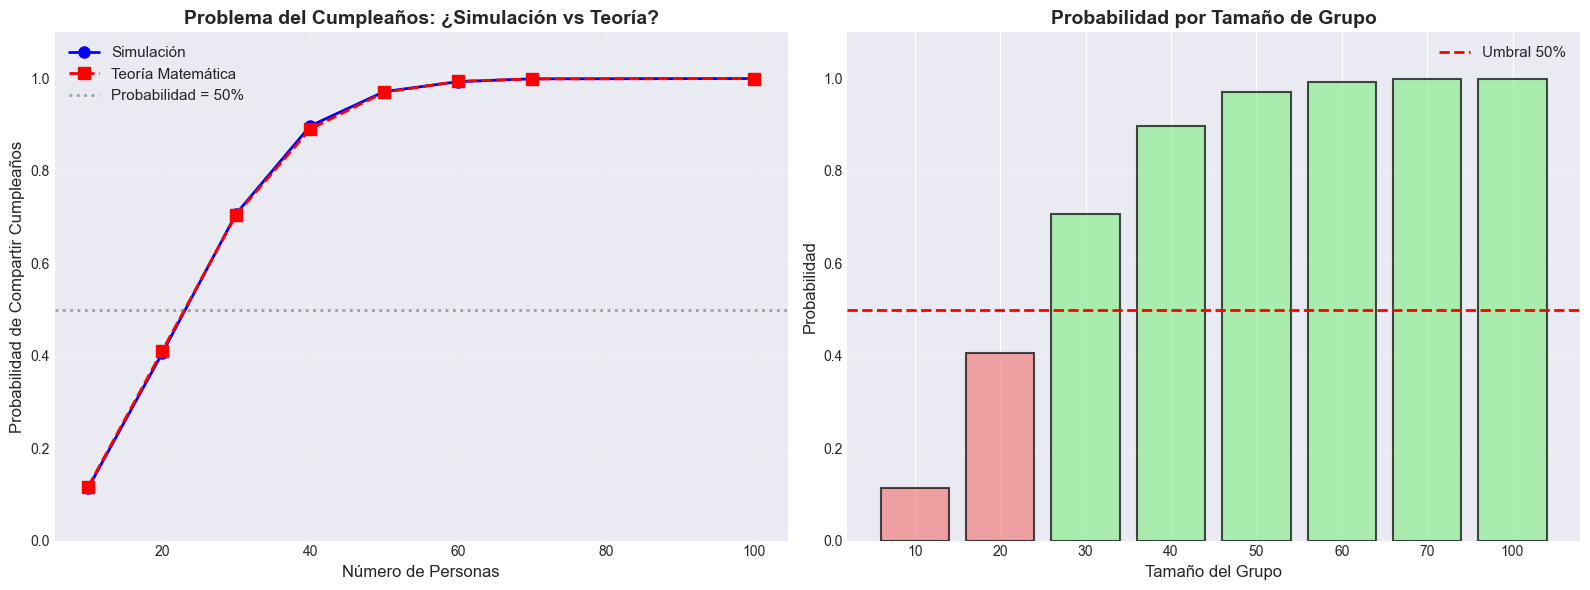


🎯 RESULTADO SORPRENDENTE:

   Con solo 30 personas:
   → La probabilidad de compartir cumpleaños es 70.8%
   → ¡Es MÁS del 50%!

--------------------------------------------------------------------------------
💡 ¿QUÉ ESPERARÍAMOS INTUITIVAMENTE?
--------------------------------------------------------------------------------
   → Hay 366 días en el año
   → Intuitivamente, pensaríamos que necesitamos ~183 personas (366/2)
   → para tener 50% de probabilidad de coincidencia

💡 ¿QUÉ MUESTRA LA SIMULACIÓN?
--------------------------------------------------------------------------------
   → Con solo 23 personas, ¡ya hay ~50% de probabilidad!
   → Con 50 personas, la probabilidad es ~97%
   → Con 70 personas, la probabilidad es ~99.9%

🎓 LECCIÓN IMPORTANTE:
--------------------------------------------------------------------------------
   La simulación nos ayuda a:
   ✓ Validar (o refutar) nuestra intuición
   ✓ Entender fenómenos contra-intuitivos
   ✓ Verificar cálculos teóricos comple

In [11]:
# ============================================================
# VISUALIZACIÓN DEL PROBLEMA DEL CUMPLEAÑOS
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- GRÁFICA 1: Comparación Simulación vs Teoría ---
axes[0].plot(tamaños_grupo, probabilidades_simuladas, 'o-', linewidth=2, markersize=8, 
             label='Simulación', color='blue')
axes[0].plot(tamaños_grupo, probabilidades_teoricas, 's--', linewidth=2, markersize=8, 
             label='Teoría Matemática', color='red')
axes[0].axhline(0.5, color='gray', linestyle=':', linewidth=2, alpha=0.7, 
                label='Probabilidad = 50%')
axes[0].set_xlabel('Número de Personas', fontsize=12)
axes[0].set_ylabel('Probabilidad de Compartir Cumpleaños', fontsize=12)
axes[0].set_title('Problema del Cumpleaños: ¿Simulación vs Teoría?', 
                  fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0, 1.1])

# --- GRÁFICA 2: Barras de Probabilidad ---
colores_barras = ['lightcoral' if p < 0.5 else 'lightgreen' for p in probabilidades_simuladas]
axes[1].bar(range(len(tamaños_grupo)), probabilidades_simuladas, 
            alpha=0.7, color=colores_barras, edgecolor='black', linewidth=1.5)
axes[1].axhline(0.5, color='red', linestyle='--', linewidth=2, 
                label='Umbral 50%')
axes[1].set_xlabel('Tamaño del Grupo', fontsize=12)
axes[1].set_ylabel('Probabilidad', fontsize=12)
axes[1].set_title('Probabilidad por Tamaño de Grupo', fontsize=14, fontweight='bold')
axes[1].set_xticks(range(len(tamaños_grupo)))
axes[1].set_xticklabels(tamaños_grupo)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].set_ylim([0, 1.1])

plt.tight_layout()
plt.show()

# ============================================================
# HALLAZGOS IMPORTANTES
# ============================================================
print("\n" + "=" * 80)
print("🎯 RESULTADO SORPRENDENTE:")
print("=" * 80)

# Encontrar el primer grupo donde P > 0.5
for i, prob in enumerate(probabilidades_simuladas):
    if prob > 0.5:
        print(f"\n   Con solo {tamaños_grupo[i]} personas:")
        print(f"   → La probabilidad de compartir cumpleaños es {prob:.1%}")
        print(f"   → ¡Es MÁS del 50%!")
        break

print("\n" + "-" * 80)
print("💡 ¿QUÉ ESPERARÍAMOS INTUITIVAMENTE?")
print("-" * 80)
print("   → Hay 366 días en el año")
print("   → Intuitivamente, pensaríamos que necesitamos ~183 personas (366/2)")
print("   → para tener 50% de probabilidad de coincidencia")
print()
print("💡 ¿QUÉ MUESTRA LA SIMULACIÓN?")
print("-" * 80)
print("   → Con solo 23 personas, ¡ya hay ~50% de probabilidad!")
print("   → Con 50 personas, la probabilidad es ~97%")
print("   → Con 70 personas, la probabilidad es ~99.9%")
print()
print("🎓 LECCIÓN IMPORTANTE:")
print("-" * 80)
print("   La simulación nos ayuda a:")
print("   ✓ Validar (o refutar) nuestra intuición")
print("   ✓ Entender fenómenos contra-intuitivos")
print("   ✓ Verificar cálculos teóricos complejos")
print("=" * 80)

In [14]:

# Encontrar el número mínimo de personas para P > 0.5
print("\n" + "=" * 80)
print("RESULTADO SORPRENDENTE:")
min_para_50_idx = next((i for i, p in enumerate(probabilidades_simuladas) if p > 0.5), None)
if min_para_50_idx is not None:
    min_para_50 = tamaños_grupo[min_para_50_idx]
    print(f"  Con solo {min_para_50} personas, la probabilidad de compartir cumpleaños > 50%")

if 70 in tamaños_grupo:
    idx_70 = tamaños_grupo.index(70)
    print(f"  Con 70 personas, la probabilidad es ~{probabilidades_simuladas[idx_70]:.1%}")
if 100 in tamaños_grupo:
    idx_100 = tamaños_grupo.index(100)
    print(f"  Con 100 personas, la probabilidad es ~{probabilidades_simuladas[idx_100]:.1%}")
print("\nInterpretación:")
print("  • La intuición sugiere que se necesitarían ~183 personas (366/2) para P > 0.5")
print("  • La realidad es que solo se necesitan ~23 personas")
print("  • Este es un ejemplo de por qué la simulación es valiosa: ayuda a desafiar intuiciones erróneas")


RESULTADO SORPRENDENTE:
  Con solo 30 personas, la probabilidad de compartir cumpleaños > 50%
  Con 70 personas, la probabilidad es ~99.9%
  Con 100 personas, la probabilidad es ~100.0%

Interpretación:
  • La intuición sugiere que se necesitarían ~183 personas (366/2) para P > 0.5
  • La realidad es que solo se necesitan ~23 personas
  • Este es un ejemplo de por qué la simulación es valiosa: ayuda a desafiar intuiciones erróneas


## 5. Caso de Estudio: El Vendedor de Periódicos (Newsvendor)

### Problema

Una tienda debe decidir cuántos productos perecederos comprar ($Q$) para vender mañana.

**Parámetros:**
- Costo por unidad: $c = 20$
- Precio de venta: $p = 50$
- Valor de salvamento (no vendido): $s = 0$
- Demanda ($D$): Incierta, sigue $N(\mu=100, \sigma=30)$

### Enfoque 1: El "Ingeniero Promedio" (Determinístico)

"Asumo que la demanda será igual al promedio: $D = \mu = 100$"

**Decisión:** Pedir $Q = 100$

**Cálculo:**
- Ventas = $100 \times 50 = 5000$
- Costo = $100 \times 20 = 2000$
- Utilidad = $3000$


In [15]:
# ============================================================
# PROBLEMA DEL VENDEDOR DE PERIÓDICOS
# ENFOQUE DETERMINÍSTICO (INGENUO)
# ============================================================

# --- PARÁMETROS DEL PROBLEMA ---
# Estos son los datos que conocemos del problema
demanda_promedio = 100       # μ: Promedio de clientes que esperamos
desviacion_demanda = 30      # σ: Qué tan variable es la demanda
precio_venta = 50            # p: ¿A cuánto vendemos cada periódico?
costo_compra = 20            # c: ¿Cuánto nos cuesta cada periódico?
valor_salvamento = 0         # s: ¿Cuánto recuperamos de lo que no vendemos?

# --- DECISIÓN DEL "INGENIERO PROMEDIO" ---
# Pensamiento: "La demanda promedio es 100, entonces compro 100 periódicos"
cantidad_a_comprar = 100

print("=" * 70)
print("PROBLEMA DEL VENDEDOR DE PERIÓDICOS")
print("=" * 70)
print("\n📋 DATOS DEL PROBLEMA:")
print(f"   • Demanda promedio (μ):        {demanda_promedio} clientes")
print(f"   • Desviación estándar (σ):     {desviacion_demanda} clientes")
print(f"   • Precio de venta (p):         ${precio_venta} por periódico")
print(f"   • Costo de compra (c):         ${costo_compra} por periódico")
print(f"   • Valor de salvamento (s):     ${valor_salvamento} por periódico")

print("\n" + "=" * 70)
print("ENFOQUE DETERMINÍSTICO (simplificado)")
print("=" * 70)
print(f"\n💭 Razonamiento del 'Ingeniero Promedio':")
print(f"   → \"La demanda promedio es {demanda_promedio}\"")
print(f"   → \"Entonces compraré exactamente {cantidad_a_comprar} periódicos\"")
print(f"   → \"Asumo que SIEMPRE venderé todos los {cantidad_a_comprar}\"")

# --- CÁLCULO DE UTILIDAD (ASUMIENDO QUE TODO SE VENDE) ---
ingresos = cantidad_a_comprar * precio_venta
costos = cantidad_a_comprar * costo_compra
utilidad_deterministica = ingresos - costos

print(f"\n📊 CÁLCULO:")
print(f"   • Ingresos: {cantidad_a_comprar} × ${precio_venta} = ${ingresos:,}")
print(f"   • Costos:   {cantidad_a_comprar} × ${costo_compra} = ${costos:,}")
print(f"   • Utilidad: ${ingresos:,} - ${costos:,} = ${utilidad_deterministica:,}")

print(f"\n✅ CONCLUSIÓN:")
print(f"   → \"Esperamos ganar ${utilidad_deterministica:,}\"")
print(f"   → \"¡Parece un buen negocio!\"")

print("\n" + "=" * 70)
print("⚠️  PERO... ¿ES ESTO REALISTA?")
print("=" * 70)
print("   ❌ Asumimos que la demanda es siempre exactamente 100")
print("   ❌ Ignoramos la variabilidad (σ = 30)")
print("   ❌ En la realidad, la demanda es ALEATORIA")
print("   ❌ Algunos días venderemos menos, otros días más")
print()
print("   👉 Veamos qué pasa cuando consideramos la incertidumbre...")
print("=" * 70)

PROBLEMA DEL VENDEDOR DE PERIÓDICOS

📋 DATOS DEL PROBLEMA:
   • Demanda promedio (μ):        100 clientes
   • Desviación estándar (σ):     30 clientes
   • Precio de venta (p):         $50 por periódico
   • Costo de compra (c):         $20 por periódico
   • Valor de salvamento (s):     $0 por periódico

ENFOQUE DETERMINÍSTICO (simplificado)

💭 Razonamiento del 'Ingeniero Promedio':
   → "La demanda promedio es 100"
   → "Entonces compraré exactamente 100 periódicos"
   → "Asumo que SIEMPRE venderé todos los 100"

📊 CÁLCULO:
   • Ingresos: 100 × $50 = $5,000
   • Costos:   100 × $20 = $2,000
   • Utilidad: $5,000 - $2,000 = $3,000

✅ CONCLUSIÓN:
   → "Esperamos ganar $3,000"
   → "¡Parece un buen negocio!"

⚠️  PERO... ¿ES ESTO REALISTA?
   ❌ Asumimos que la demanda es siempre exactamente 100
   ❌ Ignoramos la variabilidad (σ = 30)
   ❌ En la realidad, la demanda es ALEATORIA
   ❌ Algunos días venderemos menos, otros días más

   👉 Veamos qué pasa cuando consideramos la incertidumbre

### Enfoque 2: La Realidad (Estocástico)

Si pedimos $Q=100$, pero la demanda es una variable aleatoria $D$:

$$\text{Utilidad}(D, Q) = p \cdot \min(D, Q) - c \cdot Q$$

**Observaciones:**
- Si $D < Q$: Vendemos $D$, tenemos inventario sobrante (costo de oportunidad)
- Si $D > Q$: Vendemos $Q$ (stockout), perdemos ventas potenciales
- La función es **no lineal** en $D$

**El promedio de la utilidad será MENOR que la utilidad del promedio.**


In [16]:
# ============================================================
# SIMULACIÓN MONTE CARLO DEL PROBLEMA DEL VENDEDOR
# ============================================================

print("=" * 70)
print("SIMULACIÓN: Considerando la INCERTIDUMBRE")
print("=" * 70)

# --- CONFIGURACIÓN DE LA SIMULACIÓN ---
num_simulaciones = 10000  # Simularemos 10,000 días diferentes
np.random.seed(42)        # Para reproducibilidad

print(f"\n🔄 Vamos a simular {num_simulaciones:,} días de operación...")
print(f"   → Cada día, la demanda será DIFERENTE (aleatoria)")
print(f"   → Seguirá una distribución Normal(μ={demanda_promedio}, σ={desviacion_demanda})")

# --- GENERAR DEMANDAS ALEATORIAS ---
# Cada día tiene una demanda diferente
demandas_simuladas = np.random.normal(demanda_promedio, desviacion_demanda, num_simulaciones)

# Ajustes realistas:
# 1. Redondeamos (no podemos vender 0.5 periódicos)
demandas_simuladas = np.round(demandas_simuladas)

# 2. No puede haber demanda negativa
demandas_simuladas[demandas_simuladas < 0] = 0

print(f"\n📊 ESTADÍSTICAS DE LAS DEMANDAS GENERADAS:")
print(f"   • Promedio:              {np.mean(demandas_simuladas):.2f}")
print(f"   • Desviación estándar:   {np.std(demandas_simuladas):.2f}")
print(f"   • Mínima:                {np.min(demandas_simuladas):.0f}")
print(f"   • Máxima:                {np.max(demandas_simuladas):.0f}")

# --- CALCULAR VENTAS Y UTILIDADES ---
# Para cada día, calculamos cuánto vendimos y cuánto ganamos

# ¿Cuánto vendimos cada día?
# No podemos vender más de lo que compramos (cantidad_a_comprar)
# No podemos vender más de lo que pide la gente (demandas_simuladas)
ventas_reales = np.minimum(demandas_simuladas, cantidad_a_comprar)

# Utilidad de cada día = (Ingresos por ventas) - (Costo total de compra)
utilidades_por_dia = (precio_venta * ventas_reales) - (costo_compra * cantidad_a_comprar)

# --- ANÁLISIS DE RESULTADOS ---
utilidad_promedio_real = np.mean(utilidades_por_dia)
desviacion_utilidad = np.std(utilidades_por_dia)
utilidad_minima = np.min(utilidades_por_dia)
utilidad_maxima = np.max(utilidades_por_dia)
probabilidad_perdida = np.mean(utilidades_por_dia < 0)

# ============================================================
# COMPARACIÓN: DETERMINÍSTICO VS ESTOCÁSTICO
# ============================================================
print("\n" + "=" * 70)
print("📊 COMPARACIÓN DE RESULTADOS")
print("=" * 70)

print(f"\n{'Métrica':<30} {'Determinístico':<20} {'Simulación':<20}")
print("-" * 70)
print(f"{'Utilidad esperada':<30} ${utilidad_deterministica:<19,.2f} ${utilidad_promedio_real:<19,.2f}")
print(f"{'Desviación estándar':<30} ${0:<19,.2f} ${desviacion_utilidad:<19,.2f}")
print(f"{'Utilidad mínima':<30} ${utilidad_deterministica:<19,.2f} ${utilidad_minima:<19,.2f}")
print(f"{'Utilidad máxima':<30} ${utilidad_deterministica:<19,.2f} ${utilidad_maxima:<19,.2f}")
print(f"{'Prob. de pérdida':<30} {0:<19.2%} {probabilidad_perdida:<19.2%}")

# --- CÁLCULO DEL ERROR ---
error_absoluto = utilidad_deterministica - utilidad_promedio_real
error_porcentual = (error_absoluto / utilidad_deterministica) * 100

print("\n" + "=" * 70)
print("⚠️  EL ERROR DE IGNORAR LA INCERTIDUMBRE")
print("=" * 70)
print(f"\n   • El modelo determinístico predice: ${utilidad_deterministica:,.2f}")
print(f"   • La simulación muestra la realidad: ${utilidad_promedio_real:,.2f}")
print(f"\n   🚨 ERROR: ${error_absoluto:,.2f} ({error_porcentual:.2f}%)")
print(f"\n   → ¡Estábamos SOBREESTIMANDO la utilidad!")
print(f"   → La variabilidad de la demanda reduce nuestras ganancias")
print(f"   → Hay un {probabilidad_perdida:.2%} de probabilidad de PERDER dinero")

print("\n" + "=" * 70)
print("💡 LECCIONES APRENDIDAS:")
print("=" * 70)
print("   1. NO podemos usar simplemente el promedio de la demanda")
print("   2. La variabilidad tiene un COSTO")
print("   3. Necesitamos herramientas estocásticas (simulación)")
print("   4. El riesgo es REAL y debe considerarse")
print("=" * 70)

SIMULACIÓN: Considerando la INCERTIDUMBRE

🔄 Vamos a simular 10,000 días de operación...
   → Cada día, la demanda será DIFERENTE (aleatoria)
   → Seguirá una distribución Normal(μ=100, σ=30)

📊 ESTADÍSTICAS DE LAS DEMANDAS GENERADAS:
   • Promedio:              99.94
   • Desviación estándar:   30.09
   • Mínima:                0
   • Máxima:                218

📊 COMPARACIÓN DE RESULTADOS

Métrica                        Determinístico       Simulación          
----------------------------------------------------------------------
Utilidad esperada              $3,000.00            $2,398.97           
Desviación estándar            $0.00                $878.70             
Utilidad mínima                $3,000.00            $-2,000.00          
Utilidad máxima                $3,000.00            $3,000.00           
Prob. de pérdida               0.00%               2.24%              

⚠️  EL ERROR DE IGNORAR LA INCERTIDUMBRE

   • El modelo determinístico predice: $3,000.00
   • L

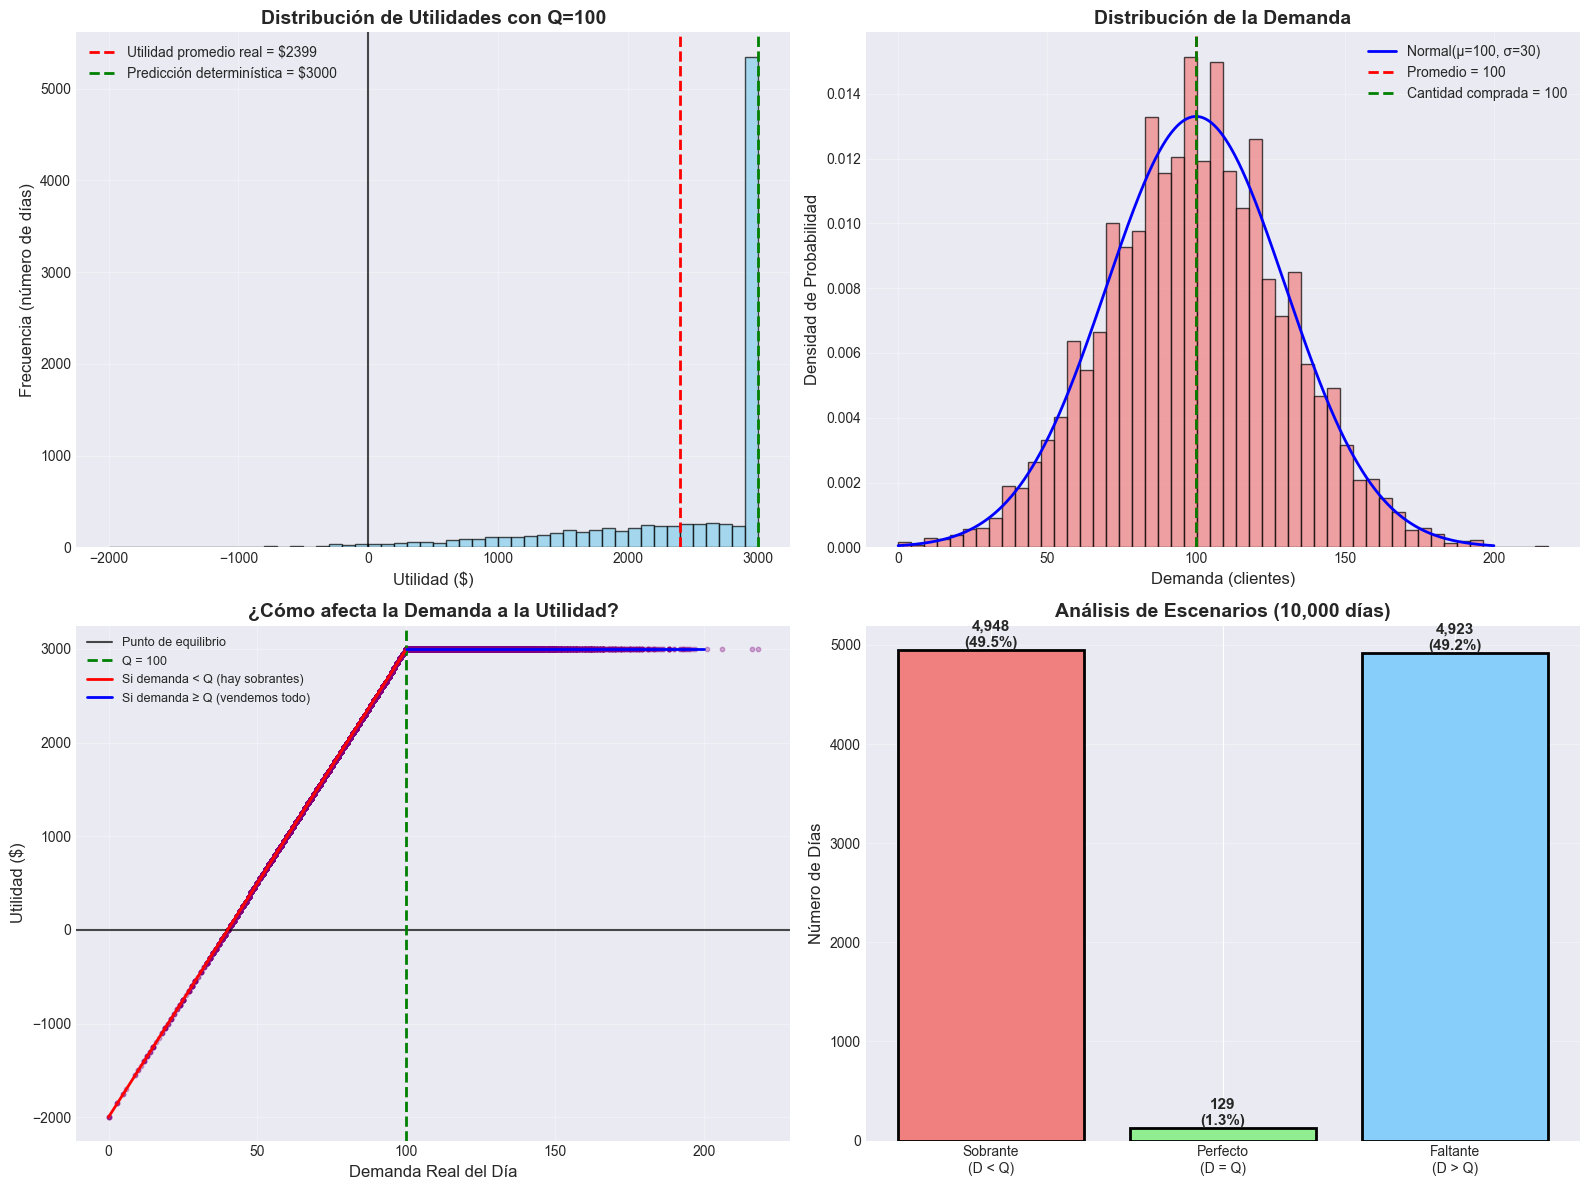


📊 ANÁLISIS DETALLADO DE ESCENARIOS

1. DÍAS CON SOBRANTE (Demanda < 100):
   → Ocurrió en 4,948 días (49.5%)
   → Utilidad promedio: $1785.32
   → Problema: Compramos más de lo necesario

2. DÍAS PERFECTOS (Demanda = 100):
   → Ocurrió en 129 días (1.3%)
   → Utilidad promedio: $3000.00
   → Situación ideal: Vendemos exactamente lo que compramos

3. DÍAS CON FALTANTE (Demanda > 100):
   → Ocurrió en 4,923 días (49.2%)
   → Utilidad promedio: $3000.00
   → Problema: Pudimos vender más, perdimos oportunidad

💡 INTERPRETACIÓN:
• En ~49% de los días tenemos inventario sobrante
• En ~49% de los días nos quedamos sin inventario
• La utilidad es máxima cuando D ≥ Q ($3000)
• La utilidad es menor cuando D < Q ($1785)


In [17]:
# ============================================================
# VISUALIZACIÓN: Problema del Vendedor de Periódicos
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- GRÁFICA 1: Distribución de Utilidades ---
axes[0, 0].hist(utilidades_por_dia, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0, 0].axvline(utilidad_promedio_real, color='red', linestyle='--', linewidth=2, 
                   label=f'Utilidad promedio real = ${utilidad_promedio_real:.0f}')
axes[0, 0].axvline(utilidad_deterministica, color='green', linestyle='--', linewidth=2, 
                   label=f'Predicción determinística = ${utilidad_deterministica:.0f}')
axes[0, 0].axvline(0, color='black', linestyle='-', linewidth=1.5, alpha=0.7)
axes[0, 0].set_xlabel('Utilidad ($)', fontsize=12)
axes[0, 0].set_ylabel('Frecuencia (número de días)', fontsize=12)
axes[0, 0].set_title('Distribución de Utilidades con Q=100', fontsize=14, fontweight='bold')
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, alpha=0.3)

# --- GRÁFICA 2: Distribución de Demandas ---
axes[0, 1].hist(demandas_simuladas, bins=50, alpha=0.7, color='lightcoral', 
                edgecolor='black', density=True)

# Agregar curva teórica de la distribución Normal
x_teorico = np.linspace(0, 200, 1000)
y_teorico = norm.pdf(x_teorico, demanda_promedio, desviacion_demanda)
axes[0, 1].plot(x_teorico, y_teorico, 'b-', linewidth=2, 
                label=f'Normal(μ={demanda_promedio}, σ={desviacion_demanda})')
axes[0, 1].axvline(demanda_promedio, color='red', linestyle='--', linewidth=2, 
                   label=f'Promedio = {demanda_promedio}')
axes[0, 1].axvline(cantidad_a_comprar, color='green', linestyle='--', linewidth=2, 
                   label=f'Cantidad comprada = {cantidad_a_comprar}')
axes[0, 1].set_xlabel('Demanda (clientes)', fontsize=12)
axes[0, 1].set_ylabel('Densidad de Probabilidad', fontsize=12)
axes[0, 1].set_title('Distribución de la Demanda', fontsize=14, fontweight='bold')
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, alpha=0.3)

# --- GRÁFICA 3: Relación Demanda vs Utilidad ---
# Esta gráfica muestra cómo cambia la utilidad según la demanda real
axes[1, 0].scatter(demandas_simuladas, utilidades_por_dia, alpha=0.3, s=10, color='purple')
axes[1, 0].axhline(0, color='black', linestyle='-', linewidth=1.5, alpha=0.7, 
                   label='Punto de equilibrio')
axes[1, 0].axvline(cantidad_a_comprar, color='green', linestyle='--', linewidth=2, 
                   label=f'Q = {cantidad_a_comprar}')

# Línea teórica: ¿qué pasa cuando la demanda es menor que Q?
demanda_baja = np.linspace(0, cantidad_a_comprar, 100)
utilidad_baja = precio_venta * demanda_baja - costo_compra * cantidad_a_comprar
axes[1, 0].plot(demanda_baja, utilidad_baja, 'r-', linewidth=2, 
                label='Si demanda < Q (hay sobrantes)')

# Línea teórica: ¿qué pasa cuando la demanda es mayor o igual que Q?
demanda_alta = np.linspace(cantidad_a_comprar, 200, 100)
utilidad_alta = precio_venta * cantidad_a_comprar - costo_compra * cantidad_a_comprar
axes[1, 0].plot(demanda_alta, [utilidad_alta]*len(demanda_alta), 'b-', linewidth=2, 
                label='Si demanda ≥ Q (vendemos todo)')

axes[1, 0].set_xlabel('Demanda Real del Día', fontsize=12)
axes[1, 0].set_ylabel('Utilidad ($)', fontsize=12)
axes[1, 0].set_title('¿Cómo afecta la Demanda a la Utilidad?', fontsize=14, fontweight='bold')
axes[1, 0].legend(fontsize=9)
axes[1, 0].grid(True, alpha=0.3)

# --- GRÁFICA 4: Análisis de Escenarios ---
# Clasificamos los días en tres escenarios
dias_sobrante = np.sum(demandas_simuladas < cantidad_a_comprar)
dias_perfecto = np.sum(demandas_simuladas == cantidad_a_comprar)
dias_faltante = np.sum(demandas_simuladas > cantidad_a_comprar)

escenarios = ['Sobrante\n(D < Q)', 'Perfecto\n(D = Q)', 'Faltante\n(D > Q)']
frecuencias = [dias_sobrante, dias_perfecto, dias_faltante]
colores = ['lightcoral', 'lightgreen', 'lightskyblue']

barras = axes[1, 1].bar(escenarios, frecuencias, color=colores, edgecolor='black', linewidth=2)
axes[1, 1].set_ylabel('Número de Días', fontsize=12)
axes[1, 1].set_title('Análisis de Escenarios (10,000 días)', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')

# Agregar valores encima de las barras
for i, (barra, freq) in enumerate(zip(barras, frecuencias)):
    altura = barra.get_height()
    porcentaje = (freq / num_simulaciones) * 100
    axes[1, 1].text(barra.get_x() + barra.get_width()/2., altura,
                    f'{int(freq):,}\n({porcentaje:.1f}%)',
                    ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================================
# ANÁLISIS DETALLADO DE ESCENARIOS
# ============================================================
print("\n" + "=" * 70)
print("📊 ANÁLISIS DETALLADO DE ESCENARIOS")
print("=" * 70)

# Calcular utilidades promedio por escenario
if dias_sobrante > 0:
    util_sobrante = np.mean(utilidades_por_dia[demandas_simuladas < cantidad_a_comprar])
else:
    util_sobrante = 0

if dias_perfecto > 0:
    util_perfecto = np.mean(utilidades_por_dia[demandas_simuladas == cantidad_a_comprar])
else:
    util_perfecto = 0

if dias_faltante > 0:
    util_faltante = np.mean(utilidades_por_dia[demandas_simuladas > cantidad_a_comprar])
else:
    util_faltante = 0

print(f"\n1. DÍAS CON SOBRANTE (Demanda < {cantidad_a_comprar}):")
print(f"   → Ocurrió en {dias_sobrante:,} días ({dias_sobrante/num_simulaciones*100:.1f}%)")
print(f"   → Utilidad promedio: ${util_sobrante:.2f}")
print(f"   → Problema: Compramos más de lo necesario")

print(f"\n2. DÍAS PERFECTOS (Demanda = {cantidad_a_comprar}):")
print(f"   → Ocurrió en {dias_perfecto:,} días ({dias_perfecto/num_simulaciones*100:.1f}%)")
if dias_perfecto > 0:
    print(f"   → Utilidad promedio: ${util_perfecto:.2f}")
else:
    print(f"   → Utilidad promedio: N/A (muy raro)")
print(f"   → Situación ideal: Vendemos exactamente lo que compramos")

print(f"\n3. DÍAS CON FALTANTE (Demanda > {cantidad_a_comprar}):")
print(f"   → Ocurrió en {dias_faltante:,} días ({dias_faltante/num_simulaciones*100:.1f}%)")
print(f"   → Utilidad promedio: ${util_faltante:.2f}")
print(f"   → Problema: Pudimos vender más, perdimos oportunidad")

print("\n" + "=" * 70)
print("💡 INTERPRETACIÓN:")
print("=" * 70)
print(f"• En ~{dias_sobrante/num_simulaciones*100:.0f}% de los días tenemos inventario sobrante")
print(f"• En ~{dias_faltante/num_simulaciones*100:.0f}% de los días nos quedamos sin inventario")
print(f"• La utilidad es máxima cuando D ≥ Q (${util_faltante:.0f})")
print(f"• La utilidad es menor cuando D < Q (${util_sobrante:.0f})")
print("=" * 70)

### Solución Analítica vs Simulación

**Solución Analítica (Newsvendor Model):**

La cantidad óptima es el fractil crítico:

$$F(Q^*) = \frac{p-c}{p-s} = \frac{50-20}{50-0} = 0.6$$

Buscamos $Q^*$ tal que $P(D \le Q^*) = 0.6$. En una Normal(100,30), esto es:

$$Q^* \approx 107.6$$

¡El modelo determinístico ($Q=100$) nos hizo pedir **menos de lo óptimo**!

La simulación nos permitirá ver esto numéricamente sin resolver la integral.


In [22]:
# Solución analítica
fractil_critico = (precio_venta - costo_compra) / (precio_venta - valor_salvamento)
Q_optimo_analitico = norm.ppf(fractil_critico, demanda_promedio, desviacion_demanda)

print("SOLUCIÓN ANALÍTICA")
print("=" * 60)
print(f"Fractil crítico: F(Q*) = (p-c)/(p-s) = {fractil_critico:.3f}")
print(f"Cantidad óptima Q*: {Q_optimo_analitico:.2f}")
print(f"\nComparación:")
print(f"  Q determinístico (promedio): {cantidad_a_comprar}")
print(f"  Q óptimo (analítico):        {Q_optimo_analitico:.2f}")
print(f"  Diferencia:                  {Q_optimo_analitico - cantidad_a_comprar:.2f} unidades")


SOLUCIÓN ANALÍTICA
Fractil crítico: F(Q*) = (p-c)/(p-s) = 0.600
Cantidad óptima Q*: 107.60

Comparación:
  Q determinístico (promedio): 100
  Q óptimo (analítico):        107.60
  Diferencia:                  7.60 unidades


### Búsqueda de la Solución Óptima mediante Simulación

Vamos a evaluar diferentes valores de $Q$ para encontrar el que maximiza la utilidad esperada.


OPTIMIZACIÓN: ¿Cuál es la MEJOR cantidad a comprar?

🔍 Probando 30 cantidades diferentes...
   Rango: desde 70 hasta 128 periódicos

✅ RESULTADO DE LA OPTIMIZACIÓN:
   → Mejor cantidad a comprar: 108 periódicos
   → Utilidad esperada: $2,417.53

📚 COMPARACIÓN CON LA TEORÍA:
   → Cantidad óptima (teoría):     107.60
   → Cantidad óptima (simulación): 108
   → Cantidad inicial (promedio):  100

💰 MEJORA AL USAR LA CANTIDAD ÓPTIMA:
   → Con Q = 100: $2,398.97
   → Con Q = 108: $2,417.53
   → Mejora: $18.56 (0.77%)


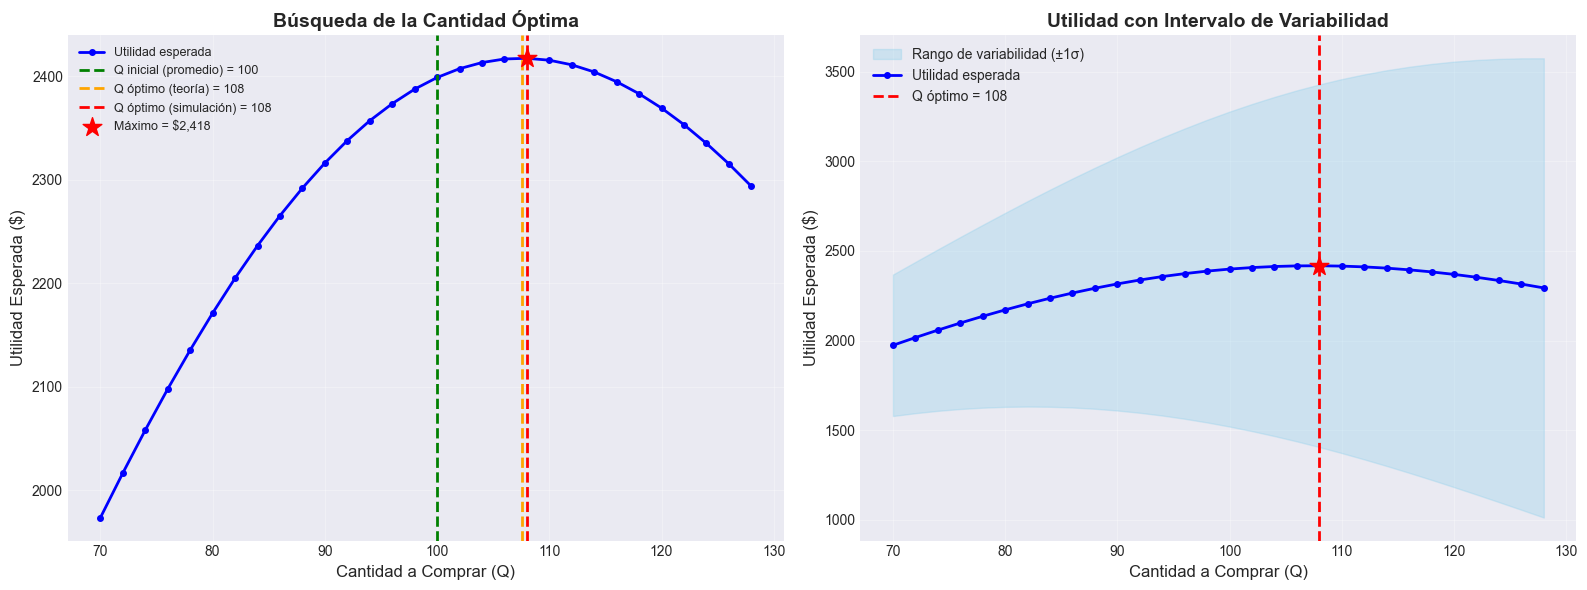


🎓 CONCLUSIONES FINALES:

1. NO debemos usar simplemente el promedio de la demanda
   → Usar Q = 100 (promedio) genera $2,398.97

2. La cantidad óptima es MAYOR que el promedio
   → Usar Q = 108 (óptimo) genera $2,417.53

3. La simulación nos ayuda a encontrar la mejor decisión
   → Mejora de $18.56 (0.8%)

4. La teoría y la simulación coinciden
   → Q* teórico = 107.6
   → Q* simulado = 108

5. Ignorar la incertidumbre es COSTOSO
   → El error puede ser del 20.0%


In [20]:
# ============================================================
# BÚSQUEDA DE LA CANTIDAD ÓPTIMA A COMPRAR
# ============================================================

print("=" * 70)
print("OPTIMIZACIÓN: ¿Cuál es la MEJOR cantidad a comprar?")
print("=" * 70)

# --- PROBAR DIFERENTES CANTIDADES ---
# Vamos a probar desde comprar 70 hasta 130 periódicos
cantidades_a_probar = np.arange(70, 130, 2)  # [70, 72, 74, ..., 128]
utilidades_promedio = []     # Guardaremos la utilidad promedio de cada cantidad
desviaciones_utilidad = []   # Guardaremos la variabilidad de cada cantidad

# Generamos las mismas demandas para todas las pruebas (para comparar justamente)
np.random.seed(42)
demandas_fijas = np.random.normal(demanda_promedio, desviacion_demanda, num_simulaciones)
demandas_fijas = np.round(demandas_fijas)
demandas_fijas[demandas_fijas < 0] = 0

print(f"\n🔍 Probando {len(cantidades_a_probar)} cantidades diferentes...")
print(f"   Rango: desde {cantidades_a_probar[0]} hasta {cantidades_a_probar[-1]} periódicos")

# --- EVALUAR CADA CANTIDAD ---
for cantidad in cantidades_a_probar:
    # Para esta cantidad, ¿cuánto vendemos cada día?
    ventas = np.minimum(demandas_fijas, cantidad)
    
    # ¿Cuál es la utilidad cada día?
    utilidades = (precio_venta * ventas) - (costo_compra * cantidad)
    
    # Guardamos el promedio y la desviación
    utilidades_promedio.append(np.mean(utilidades))
    desviaciones_utilidad.append(np.std(utilidades))

# --- ENCONTRAR LA MEJOR CANTIDAD ---
# La mejor cantidad es aquella que maximiza la utilidad promedio
indice_mejor = np.argmax(utilidades_promedio)
cantidad_optima_simulacion = cantidades_a_probar[indice_mejor]
utilidad_maxima_simulacion = utilidades_promedio[indice_mejor]

print(f"\n✅ RESULTADO DE LA OPTIMIZACIÓN:")
print(f"   → Mejor cantidad a comprar: {cantidad_optima_simulacion} periódicos")
print(f"   → Utilidad esperada: ${utilidad_maxima_simulacion:,.2f}")

# --- CALCULAR SOLUCIÓN TEÓRICA (NEWSVENDOR) ---
# La teoría dice: F(Q*) = (p-c)/(p-s)
fractil_critico = (precio_venta - costo_compra) / (precio_venta - valor_salvamento)
cantidad_optima_teorica = norm.ppf(fractil_critico, demanda_promedio, desviacion_demanda)

print(f"\n📚 COMPARACIÓN CON LA TEORÍA:")
print(f"   → Cantidad óptima (teoría):     {cantidad_optima_teorica:.2f}")
print(f"   → Cantidad óptima (simulación): {cantidad_optima_simulacion}")
print(f"   → Cantidad inicial (promedio):  {cantidad_a_comprar}")

# --- CALCULAR MEJORAS ---
# Comparar utilidades esperadas
indice_cantidad_inicial = np.argmin(np.abs(cantidades_a_probar - cantidad_a_comprar))
utilidad_cantidad_inicial = utilidades_promedio[indice_cantidad_inicial]

mejora_absoluta = utilidad_maxima_simulacion - utilidad_cantidad_inicial
mejora_porcentual = (mejora_absoluta / abs(utilidad_cantidad_inicial)) * 100

print(f"\n💰 MEJORA AL USAR LA CANTIDAD ÓPTIMA:")
print(f"   → Con Q = {cantidad_a_comprar}: ${utilidad_cantidad_inicial:,.2f}")
print(f"   → Con Q = {cantidad_optima_simulacion}: ${utilidad_maxima_simulacion:,.2f}")
print(f"   → Mejora: ${mejora_absoluta:,.2f} ({mejora_porcentual:.2f}%)")

# ============================================================
# VISUALIZACIÓN
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- GRÁFICA 1: Utilidad vs Cantidad ---
axes[0].plot(cantidades_a_probar, utilidades_promedio, 'b-', linewidth=2, 
             marker='o', markersize=4, label='Utilidad esperada')
axes[0].axvline(cantidad_a_comprar, color='green', linestyle='--', linewidth=2, 
                label=f'Q inicial (promedio) = {cantidad_a_comprar}')
axes[0].axvline(cantidad_optima_teorica, color='orange', linestyle='--', linewidth=2, 
                label=f'Q óptimo (teoría) = {cantidad_optima_teorica:.0f}')
axes[0].axvline(cantidad_optima_simulacion, color='red', linestyle='--', linewidth=2, 
                label=f'Q óptimo (simulación) = {cantidad_optima_simulacion}')
axes[0].scatter([cantidad_optima_simulacion], [utilidad_maxima_simulacion], 
                color='red', s=200, marker='*', zorder=5, 
                label=f'Máximo = ${utilidad_maxima_simulacion:,.0f}')
axes[0].set_xlabel('Cantidad a Comprar (Q)', fontsize=12)
axes[0].set_ylabel('Utilidad Esperada ($)', fontsize=12)
axes[0].set_title('Búsqueda de la Cantidad Óptima', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# --- GRÁFICA 2: Con Intervalos de Confianza ---
utilidades_superior = np.array(utilidades_promedio) + np.array(desviaciones_utilidad)
utilidades_inferior = np.array(utilidades_promedio) - np.array(desviaciones_utilidad)

axes[1].fill_between(cantidades_a_probar, utilidades_inferior, utilidades_superior, 
                     alpha=0.3, color='skyblue', label='Rango de variabilidad (±1σ)')
axes[1].plot(cantidades_a_probar, utilidades_promedio, 'b-', linewidth=2, 
             marker='o', markersize=4, label='Utilidad esperada')
axes[1].axvline(cantidad_optima_simulacion, color='red', linestyle='--', linewidth=2, 
                label=f'Q óptimo = {cantidad_optima_simulacion}')
axes[1].scatter([cantidad_optima_simulacion], [utilidad_maxima_simulacion], 
                color='red', s=200, marker='*', zorder=5)
axes[1].set_xlabel('Cantidad a Comprar (Q)', fontsize=12)
axes[1].set_ylabel('Utilidad Esperada ($)', fontsize=12)
axes[1].set_title('Utilidad con Intervalo de Variabilidad', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# CONCLUSIONES
# ============================================================
print("\n" + "=" * 70)
print("🎓 CONCLUSIONES FINALES:")
print("=" * 70)
print(f"\n1. NO debemos usar simplemente el promedio de la demanda")
print(f"   → Usar Q = {cantidad_a_comprar} (promedio) genera ${utilidad_cantidad_inicial:,.2f}")
print(f"\n2. La cantidad óptima es MAYOR que el promedio")
print(f"   → Usar Q = {cantidad_optima_simulacion} (óptimo) genera ${utilidad_maxima_simulacion:,.2f}")
print(f"\n3. La simulación nos ayuda a encontrar la mejor decisión")
print(f"   → Mejora de ${mejora_absoluta:,.2f} ({mejora_porcentual:.1f}%)")
print(f"\n4. La teoría y la simulación coinciden")
print(f"   → Q* teórico = {cantidad_optima_teorica:.1f}")
print(f"   → Q* simulado = {cantidad_optima_simulacion}")
print(f"\n5. Ignorar la incertidumbre es COSTOSO")
print(f"   → El error puede ser del {error_porcentual:.1f}%")
print("=" * 70)

## Referencias Bibliográficas

- Banks, J., Carson, J. S., Nelson, B. L., & Nicol, D. M. (2010). *Discrete-Event System Simulation*. Prentice Hall. (Capítulos 1 y 3).
- Law, A. M. (2015). *Simulation Modeling and Analysis*. McGraw-Hill Education. (Capítulo 1).
- Kulkarni, V. G. (2011). *Introduction to Modeling and Analysis of Stochastic Systems*. Springer.
